In [ ]:
import pandas as pd

## Uploading data

In [ ]:
df = pd.read_csv("/content/Guwahati_humidity.csv", skiprows=9)
df

,PARAMETER,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANN
0,QV2M,1981,8.09,8.02,9.74,12.70,16.19,18.80,19.95,20.07,18.63,14.79,11.28,9.05,13.98
1,QV2M,1982,8.15,7.43,8.67,13.16,15.64,18.48,19.43,19.87,18.29,13.87,11.04,7.86,13.52
2,QV2M,1983,6.56,5.95,7.07,9.41,15.03,17.56,18.94,19.09,18.57,15.80,10.81,7.73,12.75
3,QV2M,1984,6.36,6.19,6.62,11.53,15.66,18.58,19.31,19.30,17.38,15.41,9.97,7.71,12.85
4,QV2M,1985,6.88,6.03,8.75,12.88,14.19,17.97,18.44,19.35,18.03,14.68,9.61,7.76,12.92
5,QV2M,1986,6.90,5.92,5.86,12.22,12.94,17.02,18.52,19.05,17.57,14.00,10.86,8.23,12.46
6,QV2M,1987,7.12,7.54,8.89,11.57,13.95,18.15,19.85,19.44,19.13,14.47,11.93,9.15,13.46
7,QV2M,1988,7.34,7.35,8.03,11.86,16.53,19.00,20.34,20.07,18.84,15.60,11.93,9.82,13.91
8,QV2M,1989,6.52,6.56,7.84,10.57,15.54,18.38,19.40,19.15,18.74,16.07,10.23,7.37,13.07
9,QV2M,1990,7.46,7.53,8.98,13.12,16.02,19.06,19.88,19.72,18.62,15.04,11.89,8.56,13.85


In [ ]:
# Monthly DataFrame (JAN to DEC)
monthly_df = df[['YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN',
                 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']]


# Optional: Save to new CSVs
monthly_df.to_csv('monthly_data.csv', index=False)


In [ ]:
monthly_df

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC
0,1981,8.09,8.02,9.74,12.70,16.19,18.80,19.95,20.07,18.63,14.79,11.28,9.05
1,1982,8.15,7.43,8.67,13.16,15.64,18.48,19.43,19.87,18.29,13.87,11.04,7.86
2,1983,6.56,5.95,7.07,9.41,15.03,17.56,18.94,19.09,18.57,15.80,10.81,7.73
3,1984,6.36,6.19,6.62,11.53,15.66,18.58,19.31,19.30,17.38,15.41,9.97,7.71
4,1985,6.88,6.03,8.75,12.88,14.19,17.97,18.44,19.35,18.03,14.68,9.61,7.76
5,1986,6.90,5.92,5.86,12.22,12.94,17.02,18.52,19.05,17.57,14.00,10.86,8.23
6,1987,7.12,7.54,8.89,11.57,13.95,18.15,19.85,19.44,19.13,14.47,11.93,9.15
7,1988,7.34,7.35,8.03,11.86,16.53,19.00,20.34,20.07,18.84,15.60,11.93,9.82
8,1989,6.52,6.56,7.84,10.57,15.54,18.38,19.40,19.15,18.74,16.07,10.23,7.37
9,1990,7.46,7.53,8.98,13.12,16.02,19.06,19.88,19.72,18.62,15.04,11.89,8.56


In [ ]:
df_long = monthly_df.melt(
    id_vars='YEAR',
    value_vars=['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN',
                'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC'],
    var_name='MONTH',
    value_name='HUMIDITY'
)

# Step 2: Create proper datetime from YEAR and MONTH
month_map = {
    'JAN': 1, 'FEB': 2, 'MAR': 3, 'APR': 4,
    'MAY': 5, 'JUN': 6, 'JUL': 7, 'AUG': 8,
    'SEP': 9, 'OCT': 10, 'NOV': 11, 'DEC': 12
}

df_long['MONTH_NUM'] = df_long['MONTH'].map(month_map)

df_long['DATE'] = pd.to_datetime({
    'year': df_long['YEAR'],
    'month': df_long['MONTH_NUM'],
    'day': 1
})

# Step 3: Sort by date
df_long = df_long.sort_values('DATE')

# Optional: reset index
df_long = df_long.reset_index(drop=True)

In [ ]:
df_long

,YEAR,MONTH,HUMIDITY,MONTH_NUM,DATE
0,1981,JAN,8.09,1,1981-01-01
1,1981,FEB,8.02,2,1981-02-01
2,1981,MAR,9.74,3,1981-03-01
3,1981,APR,12.70,4,1981-04-01
4,1981,MAY,16.19,5,1981-05-01
...,...,...,...,...,...
535,2025,AUG,20.00,8,2025-08-01
536,2025,SEP,19.61,9,2025-09-01
537,2025,OCT,15.95,10,2025-10-01
538,2025,NOV,12.16,11,2025-11-01


## Distribution plot of the Humidity data

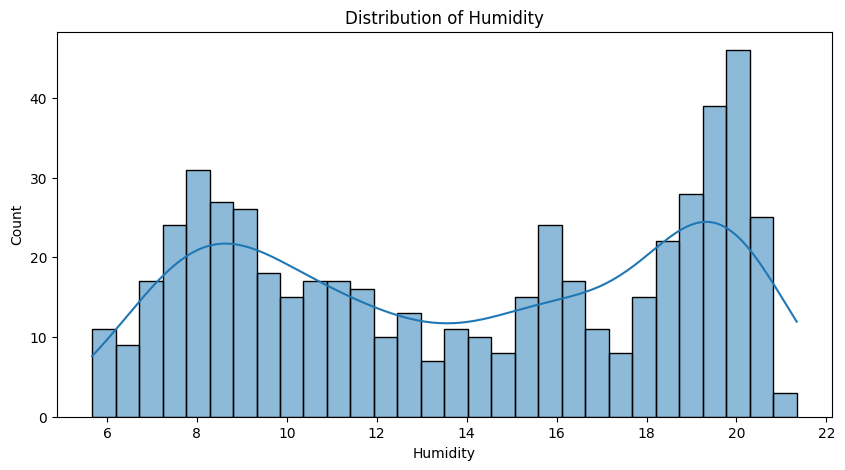

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.histplot(df_long['HUMIDITY'], bins=30, kde=True)
plt.title("Distribution of Humidity")
plt.xlabel("Humidity")
plt.ylabel("Count")
plt.show()

## Plot of our Humidity data

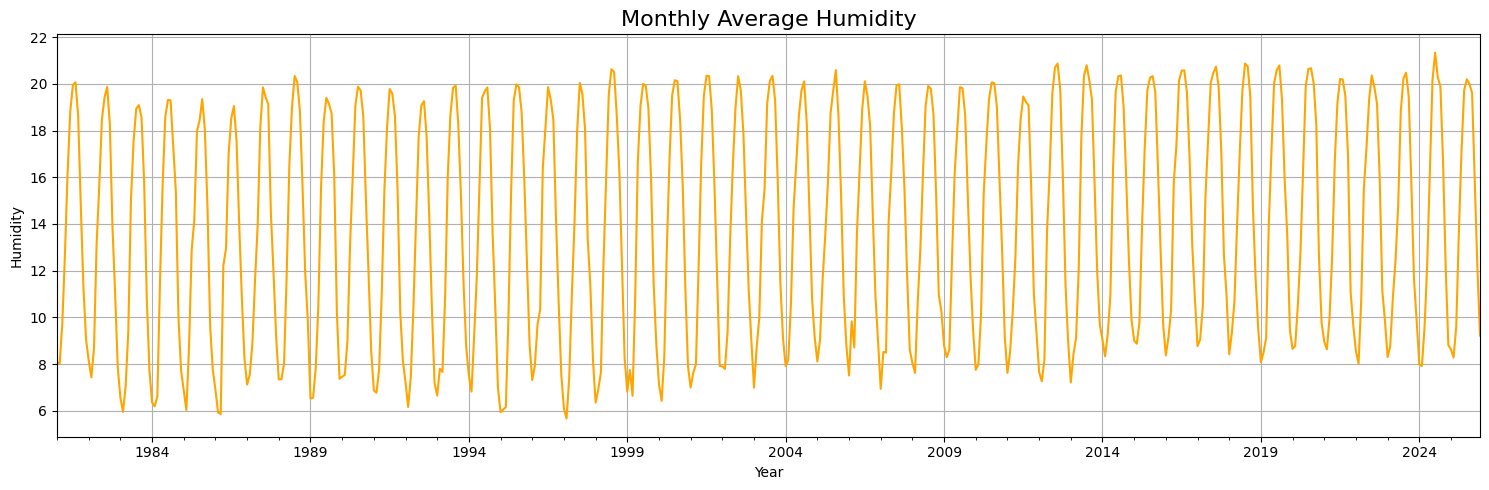

In [ ]:
import matplotlib.pyplot as plt

# Assuming your DataFrame is named `df` and DATE is datetime type

# Set DATE as index if not already
df = df_long.set_index('DATE')

# Plot the time series
plt.figure(figsize=(15, 5))
df['HUMIDITY'].plot(color='orange')
plt.title('Monthly Average Humidity', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Humidity')
plt.grid(True)
plt.tight_layout()
plt.show()

## Seasonal Decomposition

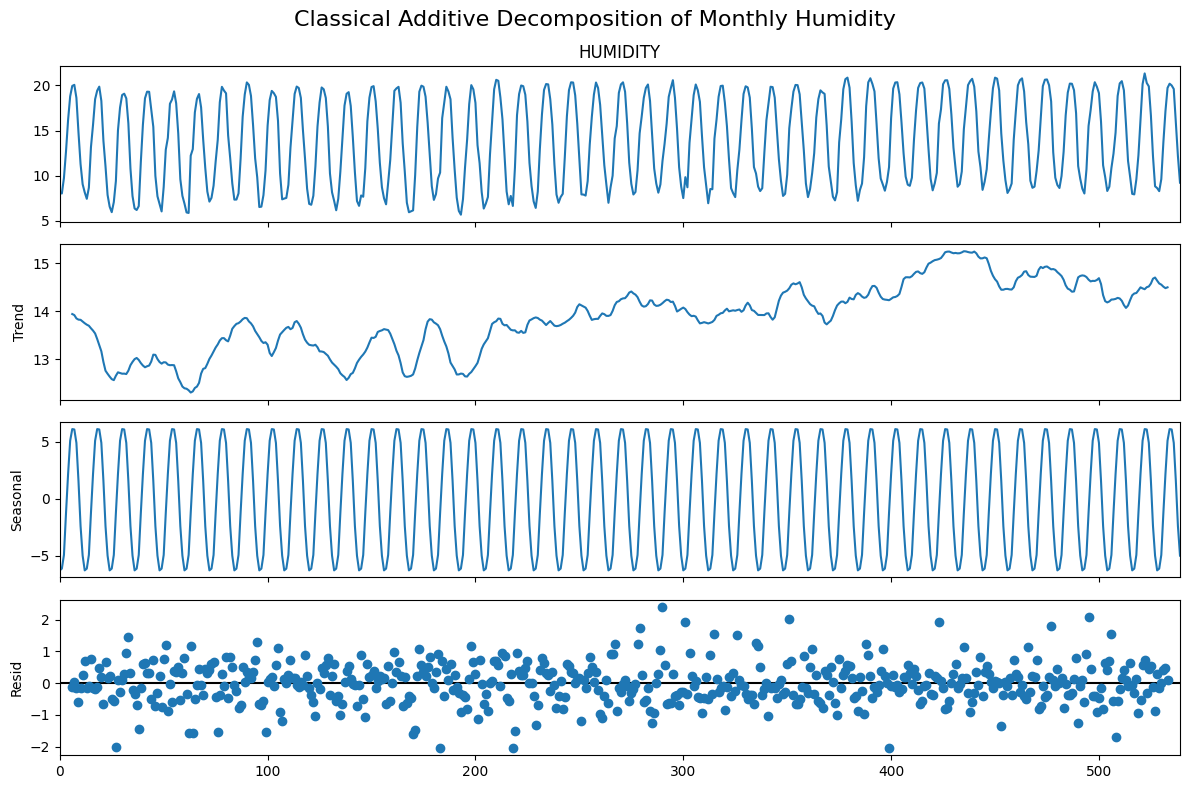

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Ensure 'DATE' is datetime and set as index (this was already done in a previous step or is the current state of df_long)
# df_long['DATE'] = pd.to_datetime(df_long['DATE'])
# df_long = df_long.set_index('DATE').sort_index()

# Perform additive decomposition (monthly → period=12)
decomposition = seasonal_decompose(df_long['HUMIDITY'], model='additive', period=12)

# Plot the decomposition
plt.rcParams.update({'figure.figsize': (12, 8)})
decomposition.plot()
plt.suptitle('Classical Additive Decomposition of Monthly Humidity', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
decomposition = seasonal_decompose(df_long['HUMIDITY'], model='additive', period=12)
# Extract each component
observed = decomposition.observed
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

decomp_df = pd.DataFrame({
    'Observed': observed,
    'Trend': trend,
    'Seasonal': seasonal,
    'Residual': residual
})

## Trend Analysis

In [ ]:
trend = decomp_df.Trend.dropna()

import numpy as np
t = np.arange(len(trend))

Linear trend

In [ ]:
from sklearn.linear_model import LinearRegression

t_reshaped = t.reshape(-1,1)
lin_model = LinearRegression().fit(t_reshaped, trend)
trend_lin = lin_model.predict(t_reshaped)

Quadratic trend

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly2 = PolynomialFeatures(degree=2)
t_poly2 = poly2.fit_transform(t_reshaped)

quad_model = LinearRegression().fit(t_poly2, trend)
trend_quad = quad_model.predict(t_poly2)

Exponential Trend

In [ ]:
log_trend = np.log(trend)

exp_model = LinearRegression().fit(t_reshaped, log_trend)
trend_exp = np.exp(exp_model.predict(t_reshaped))

Logarithmic Trend

In [ ]:
log_t = np.log(t + 1).reshape(-1,1)

log_model = LinearRegression().fit(log_t, trend)
trend_log = log_model.predict(log_t)

HP Filter (Best for Smooth Trend)

In [ ]:
from statsmodels.tsa.filters.hp_filter import hpfilter

cycle, trend_hp = hpfilter(df_long['HUMIDITY'], lamb=129600)

Model Comparison

In [ ]:
from sklearn.metrics import mean_squared_error

def rmse(actual, pred):
    return np.sqrt(mean_squared_error(actual, pred))

print("Linear RMSE:", rmse(trend, trend_lin))
print("Quadratic RMSE:", rmse(trend, trend_quad))
print("Exponential RMSE:", rmse(trend, trend_exp))
print("Logarithmic RMSE:", rmse(trend, trend_log))

Linear RMSE: 0.38144016928859054
Quadratic RMSE: 0.38142598632921104
Exponential RMSE: 0.3816093285804534
Logarithmic RMSE: 0.5225971780640734


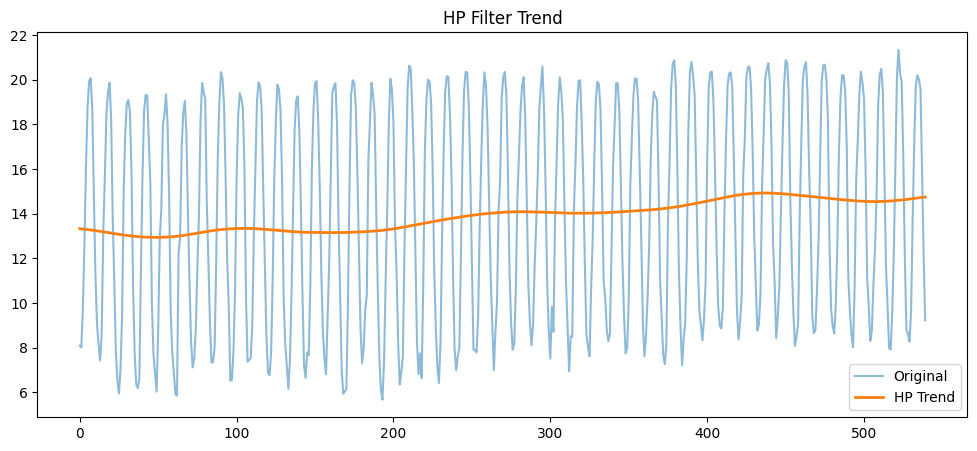

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df_long['HUMIDITY'], label='Original', alpha=0.5)
plt.plot(trend_hp, label='HP Trend', linewidth=2)
plt.legend()
plt.title("HP Filter Trend")
plt.show()

Visual Comparison

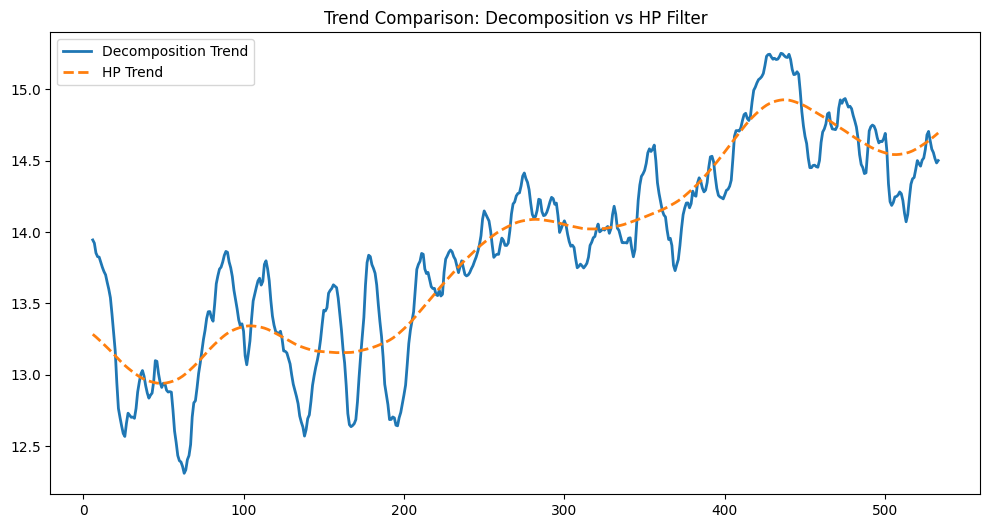

In [ ]:
trend_dec = decomposition.trend.dropna()
trend_hp_aligned = trend_hp[trend_dec.index]
plt.figure(figsize=(12,6))

plt.plot(trend_dec, label='Decomposition Trend', linewidth=2)
plt.plot(trend_hp_aligned, label='HP Trend', linestyle='--', linewidth=2)

plt.legend()
plt.title("Trend Comparison: Decomposition vs HP Filter")
plt.show()

RMSE between trends

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(trend_dec, trend_hp_aligned))
print("RMSE between trends:", rmse)

RMSE between trends: 0.27588704425526855


Correlation

In [ ]:
corr = trend_dec.corr(trend_hp_aligned)
print("Correlation:", corr)

Correlation: 0.9198733932796832


Plot Comparison

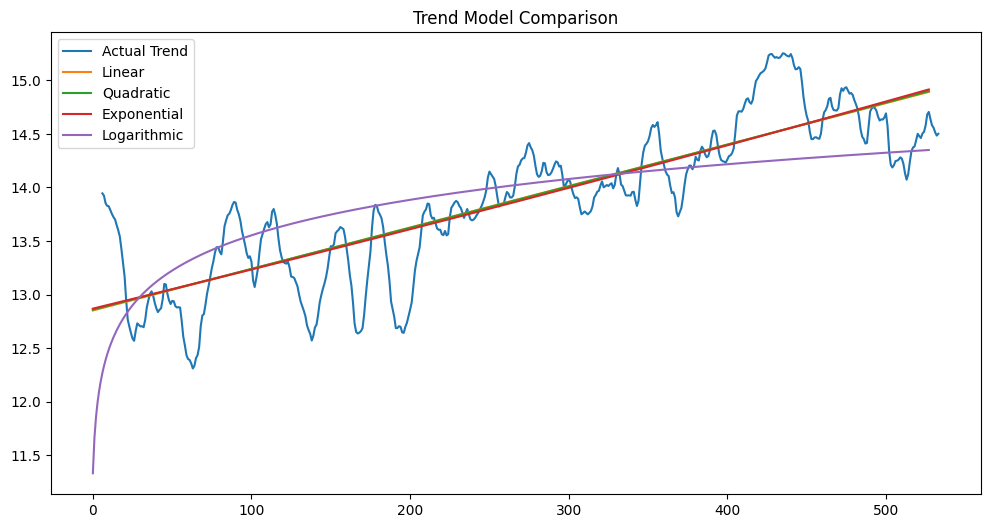

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(trend, label='Actual Trend')
plt.plot(trend_lin, label='Linear')
plt.plot(trend_quad, label='Quadratic')
plt.plot(trend_exp, label='Exponential')
plt.plot(trend_log, label='Logarithmic')

plt.legend()
plt.title("Trend Model Comparison")
plt.show()

## Checking White Noise with ACF plot

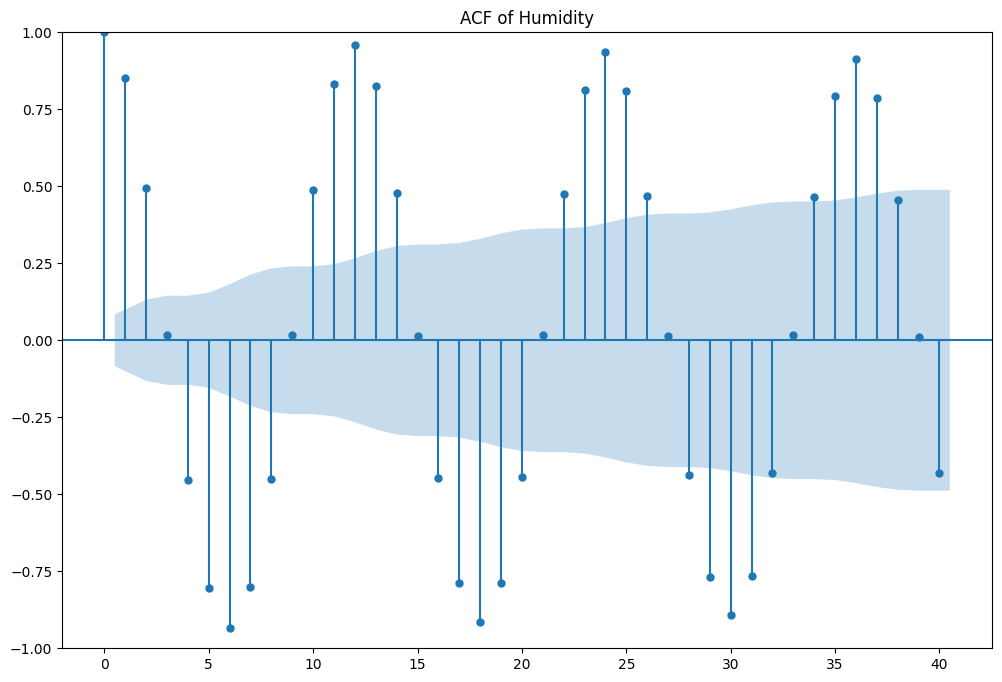

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

# If you've done decomposition:
resid = decomp_df['Observed'].dropna()

plot_acf(resid, lags=40)
plt.title('ACF of Humidity')
plt.show()


## Ljung Box test for White Noise

In [ ]:
 # Step 2: Ljung-Box test for white noise
# You can choose multiple lags, for example: 10, 20, 30
from statsmodels.stats.diagnostic import acorr_ljungbox
ljung_result = acorr_ljungbox(df_long['HUMIDITY'], lags=[10, 20, 30], return_df=True)
print("Ljung-Box Test Results:")
print(ljung_result)

Ljung-Box Test Results:
        lb_stat  lb_pvalue
10  2070.016036        0.0
20  4856.448797        0.0
30  7253.820787        0.0


 Ljung Box test suggest that it is not white noise

In [ ]:
ts = df_long['HUMIDITY']

## Train Test split

In [ ]:
train = ts[:-24]
test = ts[-24:]

In [ ]:
len(train), len(test)

(516, 24)

## ACF and PACF of Training data and did ADF and KPSS test.

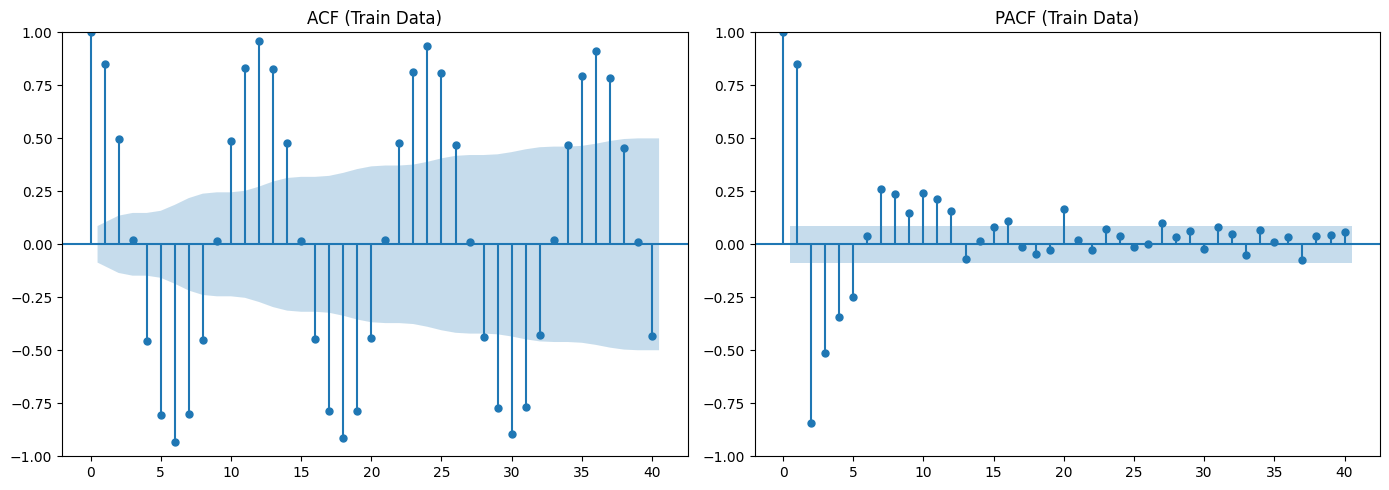

ADF Statistic: -2.1785481035266097
p-value: 0.2141231700880133
Lags Used: 19
Observations: 496
Critical Values:
   1%: -3.4436029548776395
   5%: -2.867384756137026
   10%: -2.5698830308597813

KPSS Statistic: 0.48057644488991313
p-value: 0.04604134124101056
Lags Used: 1
Critical Values:
   10%: 0.347
   5%: 0.463
   2.5%: 0.574
   1%: 0.739


In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

# =========================
# 1. ACF & PACF
# =========================
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plot_acf(train, lags=40, ax=plt.gca())
plt.title("ACF (Train Data)")

plt.subplot(1,2,2)
plot_pacf(train, lags=40, ax=plt.gca())
plt.title("PACF (Train Data)")

plt.tight_layout()
plt.show()

# =========================
# 2. ADF TEST
# =========================
adf_result = adfuller(train)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Lags Used:", adf_result[2])
print("Observations:", adf_result[3])
print("Critical Values:")
for key, val in adf_result[4].items():
    print(f"   {key}: {val}")

# =========================
# 3. KPSS TEST
# =========================
kpss_result = kpss(train, regression='c')

print("\nKPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])
print("Lags Used:", kpss_result[2])
print("Critical Values:")
for key, val in kpss_result[3].items():
    print(f"   {key}: {val}")

Both ADF and KPSS suggest it is not stationary.

## First Order differencing on training data and did ADF and KPSS test

In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss

# 🔹 First-order differencing
train_diff1 = train.diff().dropna()

# =========================
# ADF TEST
# =========================
adf_result = adfuller(train_diff1)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Lags Used:", adf_result[2])
print("Observations:", adf_result[3])
print("Critical Values:")
for key, val in adf_result[4].items():
    print(f"   {key}: {val}")

# =========================
# KPSS TEST
# =========================
kpss_result = kpss(train_diff1, regression='c')

print("\nKPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])
print("Lags Used:", kpss_result[2])
print("Critical Values:")
for key, val in kpss_result[3].items():
    print(f"   {key}: {val}")

ADF Statistic: -7.555014724314066
p-value: 3.116101039766419e-11
Lags Used: 19
Observations: 495
Critical Values:
   1%: -3.4436298692815304
   5%: -2.867396599893435
   10%: -2.5698893429241916

KPSS Statistic: 0.007796044986757986
p-value: 0.1
Lags Used: 1
Critical Values:
   10%: 0.347
   5%: 0.463
   2.5%: 0.574
   1%: 0.739


/tmp/ipykernel_20895/2341424198.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(train_diff1, regression='c')


First order differencing gives stationarity in data .

## ACF and PACF plot on 1st order  differencing train data

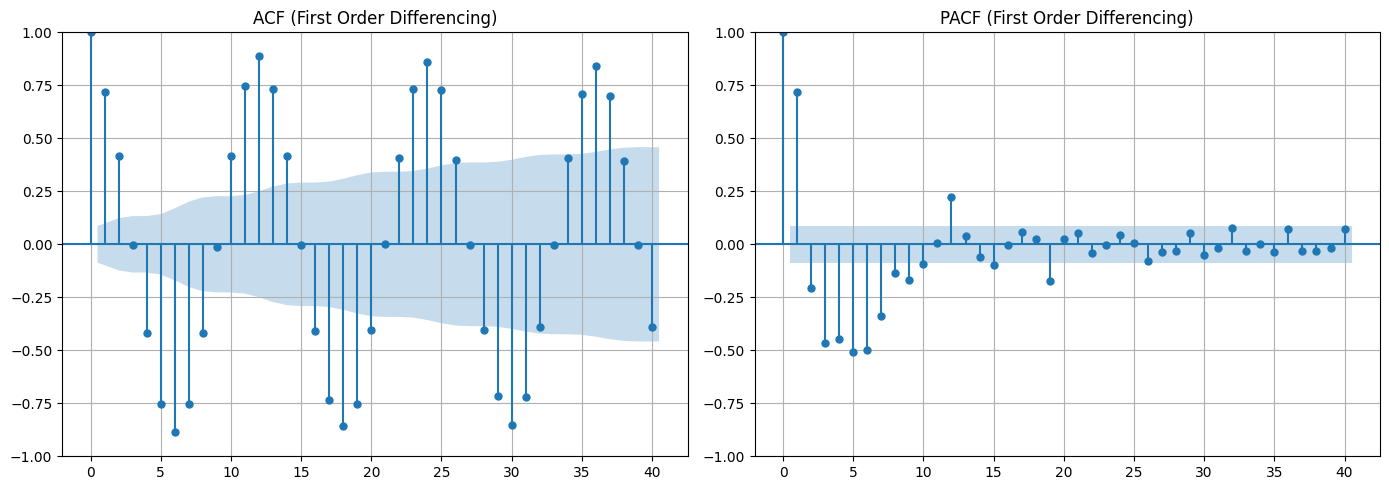

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf



# =========================
# ACF & PACF
# =========================
plt.figure(figsize=(14,5))

# ACF
plt.subplot(1,2,1)
ax1 = plt.gca()
plot_acf(train_diff1, lags=40, ax=ax1)
ax1.set_title("ACF (First Order Differencing)")
ax1.grid(True)

# PACF
plt.subplot(1,2,2)
ax2 = plt.gca()
plot_pacf(train_diff1, lags=40, ax=ax2, method='ywm')
ax2.set_title("PACF (First Order Differencing)")
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_squared_error

# Your split
# train = ts[:-24]
# test  = ts[-24:]

p_values = [1,2,3]
q_values = [1,2]

results = []

for p, q in itertools.product(p_values, q_values):
    try:
        model = SARIMAX(train,
                        order=(p,1,q),
                        seasonal_order=(1,1,1,12),
                        enforce_stationarity=False,
                        enforce_invertibility=False)

        fitted = model.fit(disp=False)

        # Forecast
        forecast = fitted.forecast(steps=len(test))

        # Metrics
        rmse = np.sqrt(mean_squared_error(test, forecast))
        nrmse = rmse / test.mean()

        # Residuals
        residuals = fitted.resid

        results.append({
            'Model': f"SARIMA({p},1,{q})(1,1,1,12)",
            'RMSE': rmse,
            'NRMSE_mean': nrmse,
            'Resid_Mean': residuals.mean(),
            'Resid_STD': residuals.std(),
            'ACF_lag1': residuals.autocorr(lag=1),
            'Model_obj': fitted
        })

    except Exception as e:
        print(f"Error in ({p},{q}):", e)

# Create DataFrame
results_df = pd.DataFrame(results)

# Sort by RMSE
results_df = results_df.sort_values(by='RMSE').reset_index(drop=True)

# Show comparison table
print(results_df[['Model','RMSE','NRMSE_mean','Resid_Mean','Resid_STD','ACF_lag1']])

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                     Model      RMSE  NRMSE_mean  Resid_Mean  Resid_STD  \
0  SARIMA(1,1,1)(1,1,1,12)  0.502701    0.034724    0.039618   0.906234   
1  SARIMA(2,1,2)(1,1,1,12)  0.505324    0.034905    0.041243   0.949785   
2  SARIMA(3,1,2)(1,1,1,12)  0.525045    0.036267    0.034997   0.909669   
3  SARIMA(1,1,2)(1,1,1,12)  0.609660    0.042112    0.043128   0.875295   
4  SARIMA(3,1,1)(1,1,1,12)  0.634471    0.043826    0.029660   0.899244   
5  SARIMA(2,1,1)(1,1,1,12)  0.638820    0.044126    0.054628   0.897125   

   ACF_lag1  
0  0.042890  
1  0.241562  
2  0.148320  
3 -0.014005  
4  0.047652  
5  0.042520  


In [ ]:
best = results_df.iloc[0]
best_model = best['Model_obj']

print("\nBest Model:")
print(best[['Model','RMSE','NRMSE_mean']])


Best Model:
Model         SARIMA(1,1,1)(1,1,1,12)
RMSE                         0.502701
NRMSE_mean                   0.034724
Name: 0, dtype: object


Residual Diagnostics (Best Model)

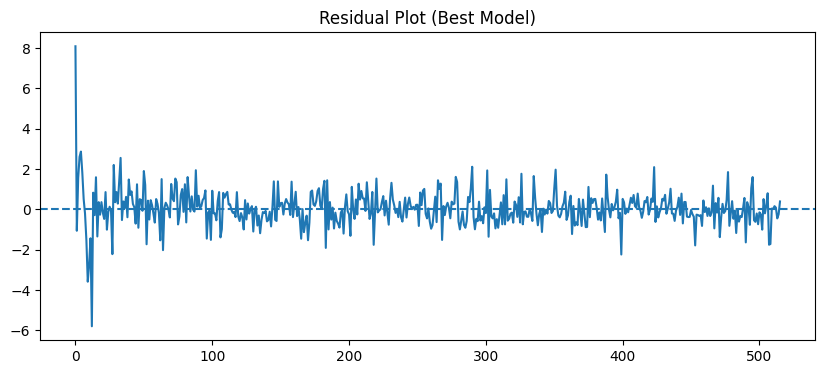

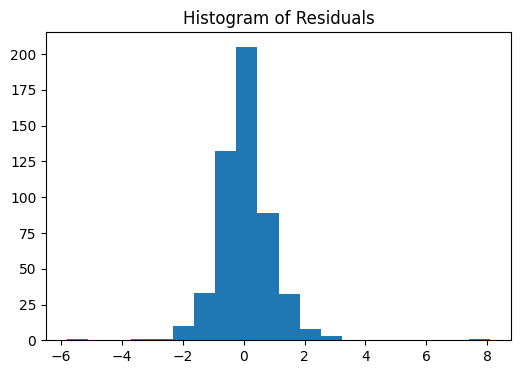

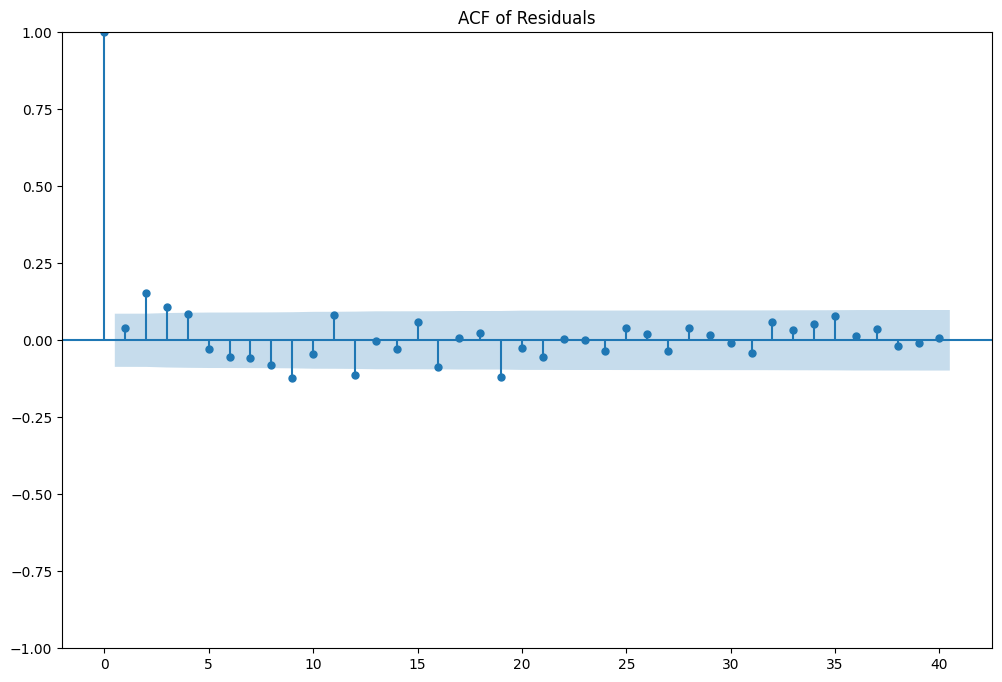

In [ ]:
residuals = best_model.resid

# Residual Plot
plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.axhline(0, linestyle='--')
plt.title("Residual Plot (Best Model)")
plt.show()

# Histogram
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=20)
plt.title("Histogram of Residuals")
plt.show()

# ACF
plot_acf(residuals, lags=40)
plt.title("ACF of Residuals")
plt.show()

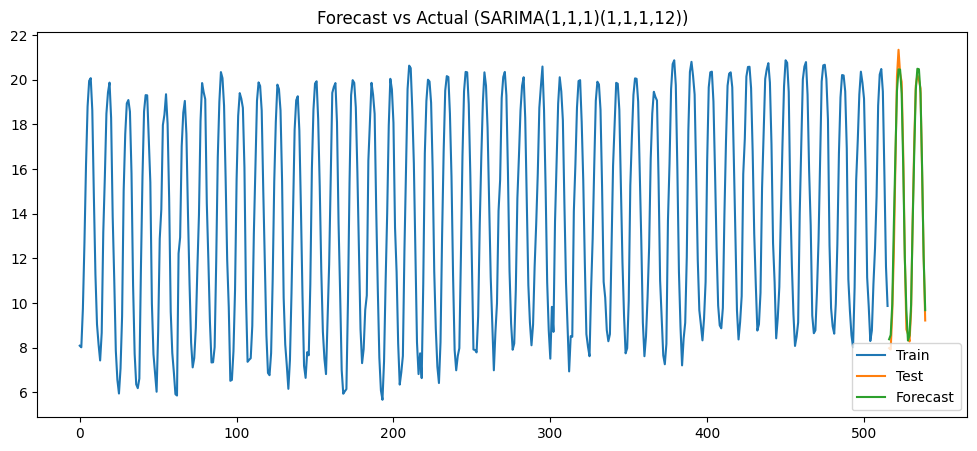

In [ ]:
forecast = best_model.forecast(steps=len(test))

plt.figure(figsize=(12,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, forecast, label='Forecast')

plt.legend()
plt.title(f"Forecast vs Actual ({best['Model']})")
plt.show()

## Doing Forecasting

# Refit Model on Full Data

In [ ]:
full_series = ts  # entire dataset

from statsmodels.tsa.statespace.sarimax import SARIMAX

final_model = SARIMAX(full_series,
                      order=(1,1,1),
                      seasonal_order=(1,1,1,12),
                      enforce_stationarity=False,
                      enforce_invertibility=False)

final_fitted = final_model.fit(disp=False)

In [ ]:
forecast_36 = final_fitted.forecast(steps=36)

In [ ]:
ts.index = pd.to_datetime(df_long['DATE'])
ts = ts.asfreq('MS')   # Monthly Start

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

final_model = SARIMAX(ts,
                      order=(1,1,1),
                      seasonal_order=(1,1,1,12),
                      enforce_stationarity=False,
                      enforce_invertibility=False)

final_fitted = final_model.fit(disp=False)

In [ ]:
forecast_36 = final_fitted.forecast(steps=36)

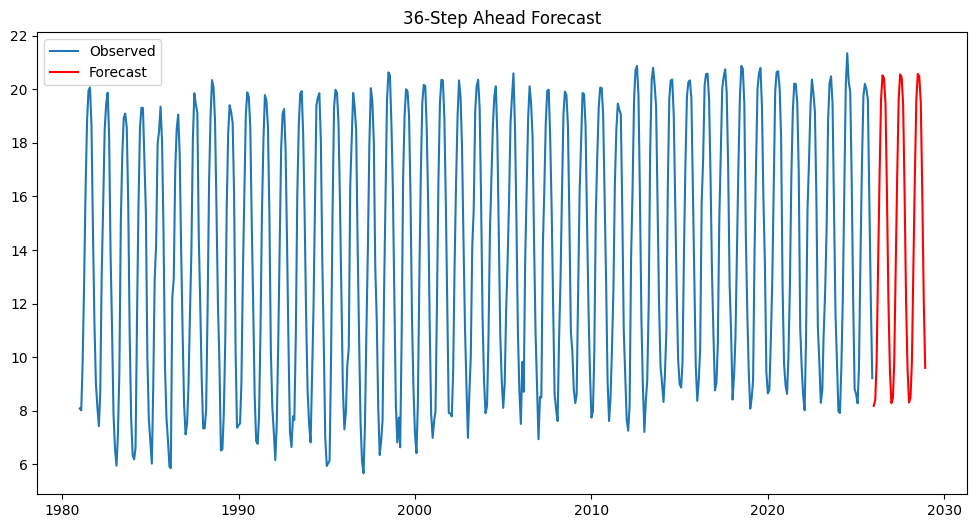

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(ts, label='Observed')
plt.plot(forecast_36, label='Forecast', color='red')

plt.legend()
plt.title("36-Step Ahead Forecast")
plt.show()

In [ ]:
print(final_fitted.summary())

                                     SARIMAX Results                                      
Dep. Variable:                           HUMIDITY   No. Observations:                  540
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -560.993
Date:                            Tue, 28 Apr 2026   AIC                           1131.986
Time:                                    10:01:08   BIC                           1153.188
Sample:                                01-01-1981   HQIC                          1140.297
                                     - 12-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3658      0.044      8.402      0.000       0.280       0.451
ma.L1         -0.9578      0.018   

In [ ]:
params = final_fitted.params
print(params)

ar.L1       0.365815
ma.L1      -0.957831
ar.S.L12    0.051065
ma.S.L12   -0.934668
sigma2      0.495527
dtype: float64


## Holt Winter Method

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(train,
                                trend='add',
                                seasonal='add',
                                seasonal_periods=12)

hw_fit = hw_model.fit()

In [ ]:
hw_forecast = hw_fit.forecast(steps=len(test))

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_hw = np.sqrt(mean_squared_error(test, hw_forecast))
nrmse_hw = rmse_hw / test.mean()

print("Holt-Winters RMSE:", rmse_hw)
print("Holt-Winters NRMSE:", nrmse_hw)

Holt-Winters RMSE: 0.5085871281152387
Holt-Winters NRMSE: 0.035130496689496984


In [ ]:
residuals_hw = train - hw_fit.fittedvalues

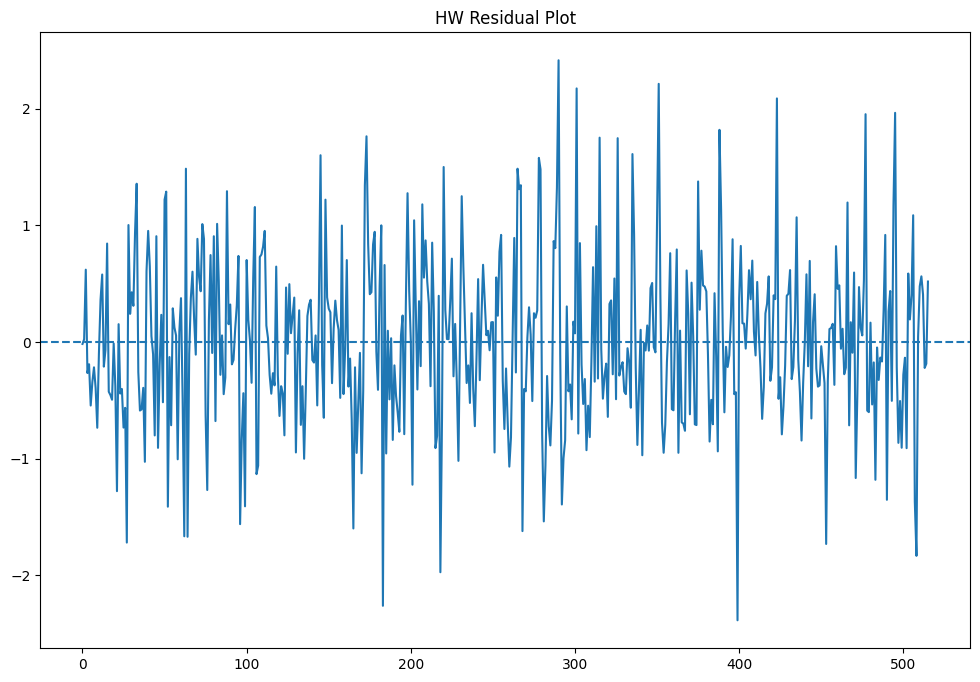

In [ ]:
import matplotlib.pyplot as plt

plt.plot(residuals_hw)
plt.axhline(0, linestyle='--')
plt.title("HW Residual Plot")
plt.show()

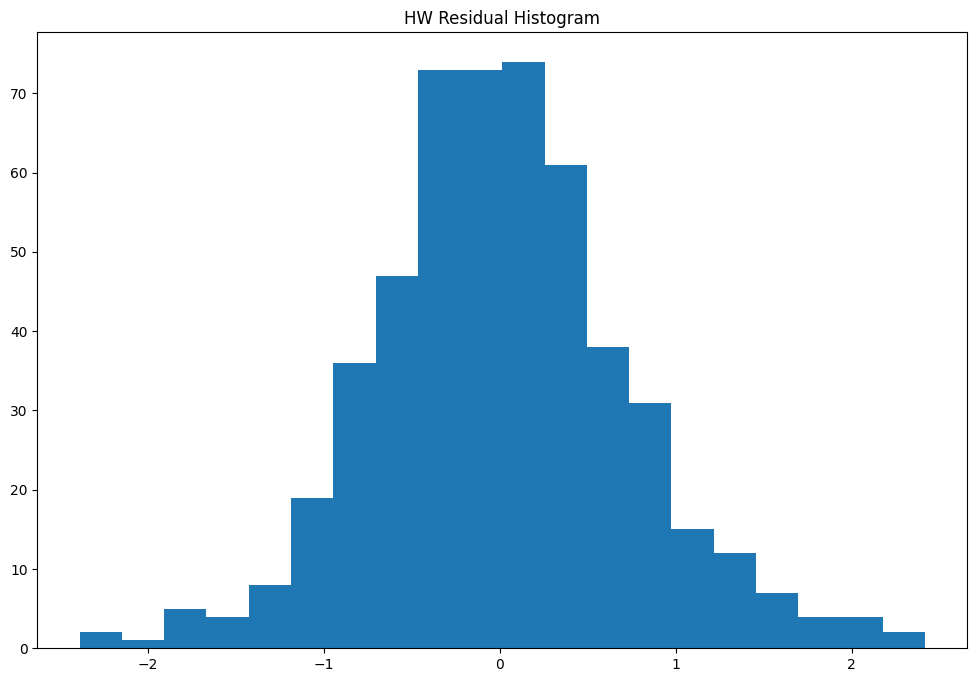

In [ ]:
plt.hist(residuals_hw, bins=20)
plt.title("HW Residual Histogram")
plt.show()

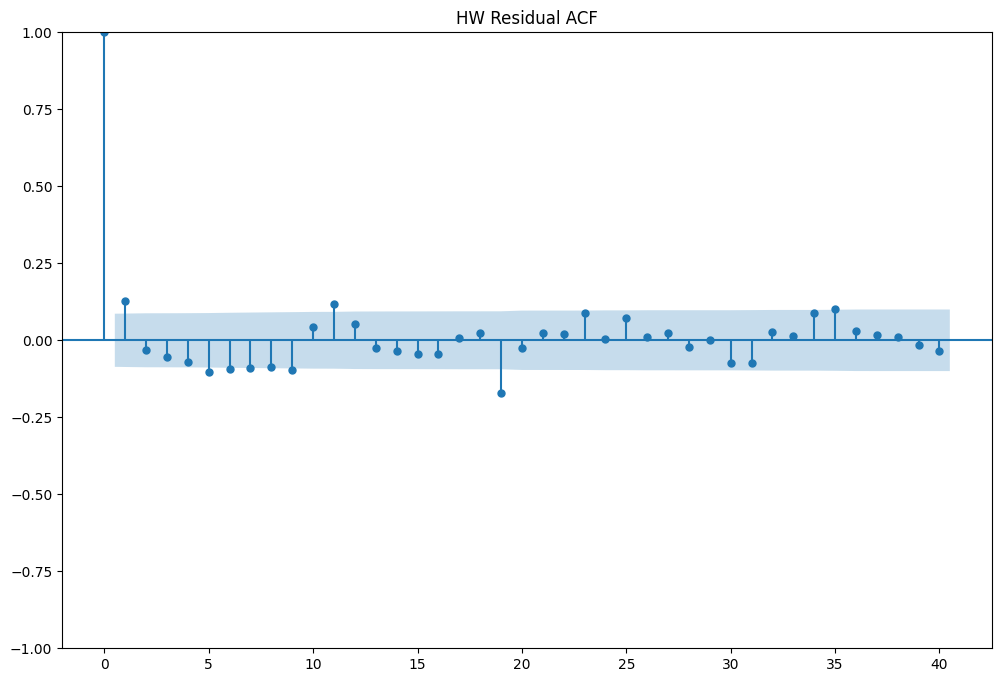

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuals_hw, lags=40)
plt.title("HW Residual ACF")
plt.show()

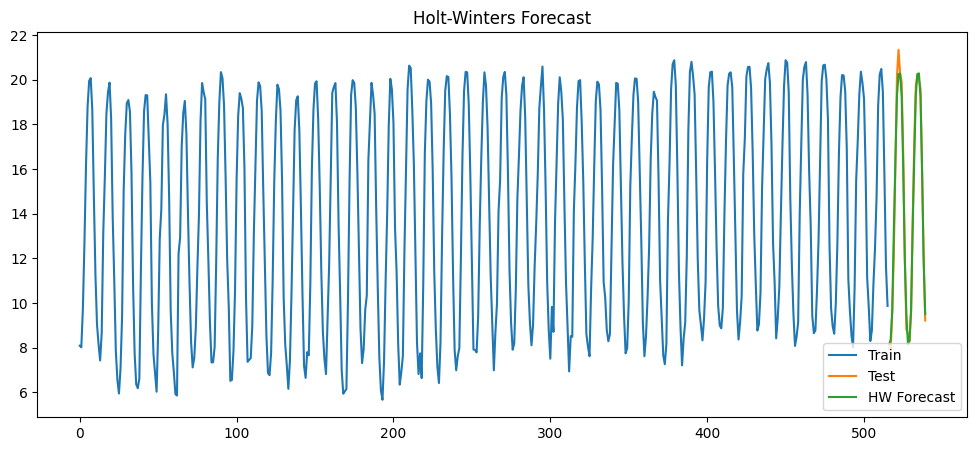

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(test.index, hw_forecast, label='HW Forecast')

plt.legend()
plt.title("Holt-Winters Forecast")
plt.show()

In [ ]:
hw_final = ExponentialSmoothing(ts,
                                trend='add',
                                seasonal='add',
                                seasonal_periods=12).fit()

hw_forecast_36 = hw_final.forecast(36)

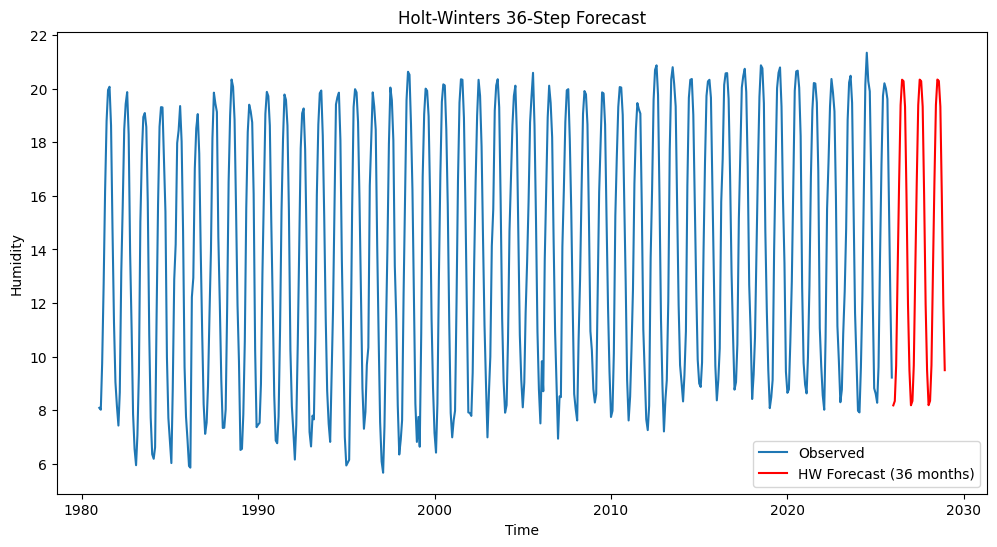

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(ts, label='Observed')
plt.plot(hw_forecast_36, label='HW Forecast (36 months)', color='red')

plt.legend()
plt.title("Holt-Winters 36-Step Forecast")
plt.xlabel("Time")
plt.ylabel("Humidity")

plt.show()